# Exploratory Data Analysis (EDA): COVID-19 Impact on Graduate Outcomes
**Research Question:** What was the effect of graduating during the COVID-19 economic downturn on starting salaries and full-time employment rates (FTE) of fresh Australian undergraduates in 2020 compared to the pre-pandemic cohort of 2018?

In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np 

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Load the cleaned dataset 
df = pd.read_csv("../data/clean/final_pandemic_research_data.csv")
print("Data loaded successfully!")
df.head() 

Data loaded successfully!


,Study_Area,Salary_18,Salary_20,FTE_18,FTE_20,Salary_Diff,FTE_Diff
0,Science and mathematics,61000,64000.0,64.6,59.1,3000.0,-5.5
1,Computing and Information Systems,60000,65000.0,73.2,72.1,5000.0,-1.1
2,Engineering,65000,69500.0,83.1,83.0,4500.0,-0.1
3,Architecture and built environment,58700,64700.0,77.7,67.7,6000.0,-10.0
4,Agriculture and environmental studies,58300,61500.0,68.3,67.4,3200.0,-0.9


In [3]:
# This describes the characteristics of all the data in the dataset without 'All' and 'Standard Deviation' columns
# This ensures our 'Characteristics' and 'Correlations' are mathemtically accurate representation of the data
df_analysis =df[~df['Study_Area'].isin(['All', 'Standard deviation'])].copy()

# Now we can describe the 'Salary_Diff' and 'FTE_Diff' columns to understand their distribution and central tendencies
df_analysis[['Salary_Diff', 'FTE_Diff']].describe()

,Salary_Diff,FTE_Diff
count,21.000000,21.000000
mean,3014.285714,-4.523810
std,1445.782042,2.840582
min,0.000000,-10.000000
25%,2400.000000,-6.500000
50%,2800.000000,-5.200000
75%,4200.000000,-2.000000
max,6000.000000,-0.100000


### Justification: Data Characteristics 
The dataset provides a precise look at 21 distinct study areas: 
- **Universal Downturn:** The max value for FTE_Diff is -0.1%, revealing that every single study area experienced a decline in full-time employment during the pandemic. 
- **Resilient Wages:** Despite the employment drop, the average salary increased by $3,014, suggesting that entry-level Wages were protected or "sticky" despite lower hiring volumes. 
- **Cleaning Note:** Filtering the summary rows was essential to ensure the mean and std calculations accurately reflect the variation between individual fields of study rather than including aggregate national totals. 

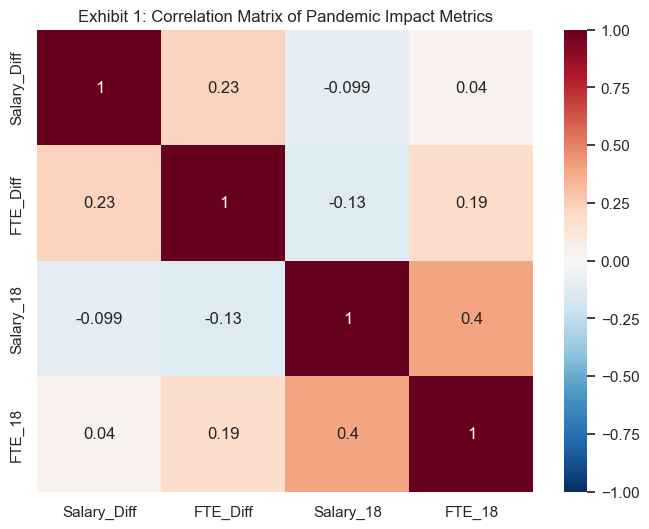

In [4]:
# 2. Exploratory Analysis: Correlation Heatmap
# We use df_analysis to ensure summary rows do not distort the correlation
plt.figure(figsize=(8, 6))

# Calculate the correlation between our key metrics
correlation_matrix = df_analysis[['Salary_Diff', 'FTE_Diff', 'Salary_18', 'FTE_18']].corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)

plt.title("Exhibit 1: Correlation Matrix of Pandemic Impact Metrics")
plt.show()

### Justification: Exploratory Correlation Analysis (Exhibit 1)
This correlation matrix tests for a "first-order effect" between the economic downturn and graduate outcomes: 
- **Weak Correlation (0.23):** There is only a weak positive correlation between Salary_Diff and FTE_Diff. This indicates that the decline in full-time employment rates did not strictly dictate the change in starting salaries. 
- **What is learned:** The economic shock of COVID-19 impacted job quantity (FTE) much more severely and consistently than job price (Salary). This suggests that entry-level professional salaries in Australia possess "downward rigidity". This means that they do not drop easily even when demand for labor falls. 
- **Modelling Note:** Since the correlation is weak, a simple linear model may not capture the full story. Future modelling should investigate if industry-specific factors (i.e, being an essential service) are better predictors than the general economic trend. 

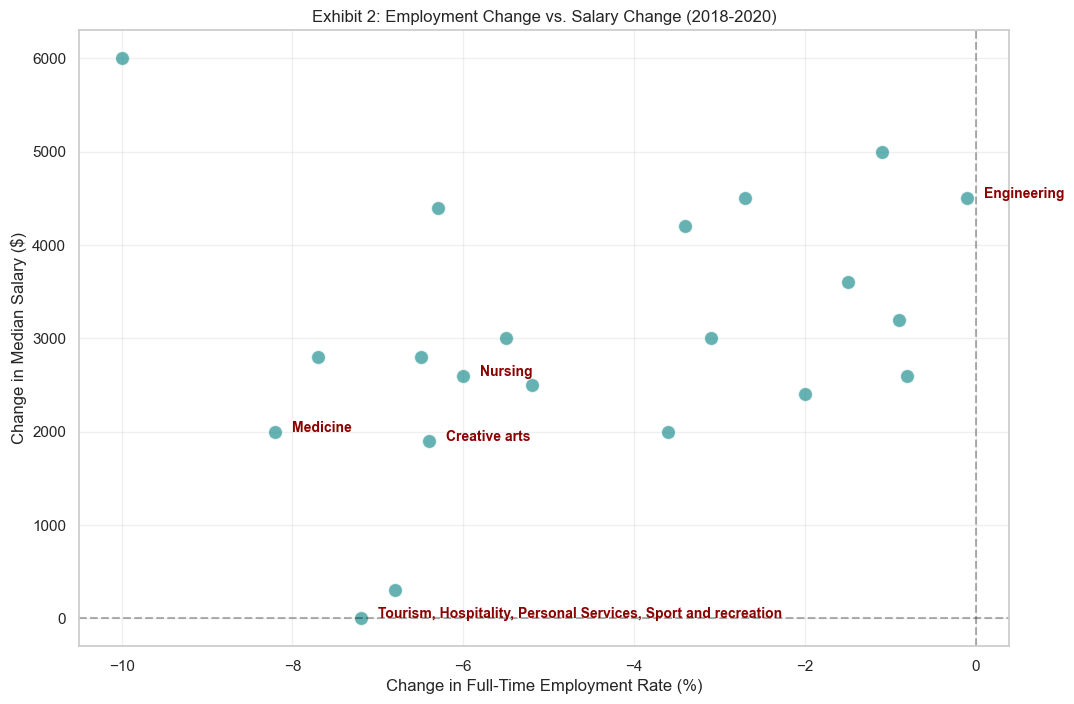

In [5]:
# 3. Targeted Impact Analysis: Salary vs Employment Change
plt.figure(figsize=(12, 8))

# Create the scatter plot using our cleaned analysis data
# FIX: Changed 'FTE_diff' to 'FTE_Diff' (Capital D)
sns.scatterplot(data=df_analysis, x='FTE_Diff', y='Salary_Diff', s=100, color='teal', alpha=0.6)

# Add a horizontal and vertical line at 0 to show the 'Quadrant of Impact' 
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Highlight and label our targets + comparative extremes
targets = ['Engineering', 'Nursing', 'Tourism', 'Medicine', 'Creative arts']
for i in range(df_analysis.shape[0]):
    area = df_analysis.Study_Area.iloc[i]
    if any(t in area for t in targets):
        # FIX: Ensure we use 'FTE_Diff' and ' darkred'
        plt.text(df_analysis.FTE_Diff.iloc[i] + 0.2,
                 df_analysis.Salary_Diff.iloc[i],
                 area, fontsize=10, fontweight='bold', color='darkred')
        
plt.title("Exhibit 2: Employment Change vs. Salary Change (2018-2020)")
plt.xlabel("Change in Full-Time Employment Rate (%)")
plt.ylabel("Change in Median Salary ($)")
plt.grid(True, alpha=0.3)
plt.show()

### Justification: Targeted Industry Analysis (Exhibit 2) 
The scatter plot helps explain why we did not find a strong link between salary and jobs in Exhibit 1. It is because different industries reacted in completely different ways:
- **Strongest Industries** **Engineering** and **Nursing** are in the top-right of the chart. This means they were safe bets. Even during the pandemic, they kept their high employment rates and still gave graduates a good pay raise. 
- **Hardest Hit Industries:** **Tourism** and **Creative Arts** are at the bottom-left. This confirms that jobs that require being there in person or are considered luxuries suffered the most, with both job losses and frozen pay.
- **Simpson's Paradox Note:** Usually, we think of "Health" as one big group that is always safe. However, the scatter plot shows a surprise: though **Nursing** stayed strong, **Medicine** saw a huge drop in full-time jobs. If we just looked at a Health average, we would miss the fact that doctors and nurses actually had very different experiences. 
- **Future Modelling Decisions:** 1. **Handling Zeroes:** Since **Tourism** had exactly $0 growth, a standard model might struggle with that flat number. In the future, we might need to use a different math formula (i.e., a Log transformation) to handle these "floor" values.
2. **Adding Categories:** Future research should group industries by whether they can "Work from Home" or are an "Essential Service." The chart suggests that how you work (in-person vs. remote) mattered more than anything else during the pandemic. 

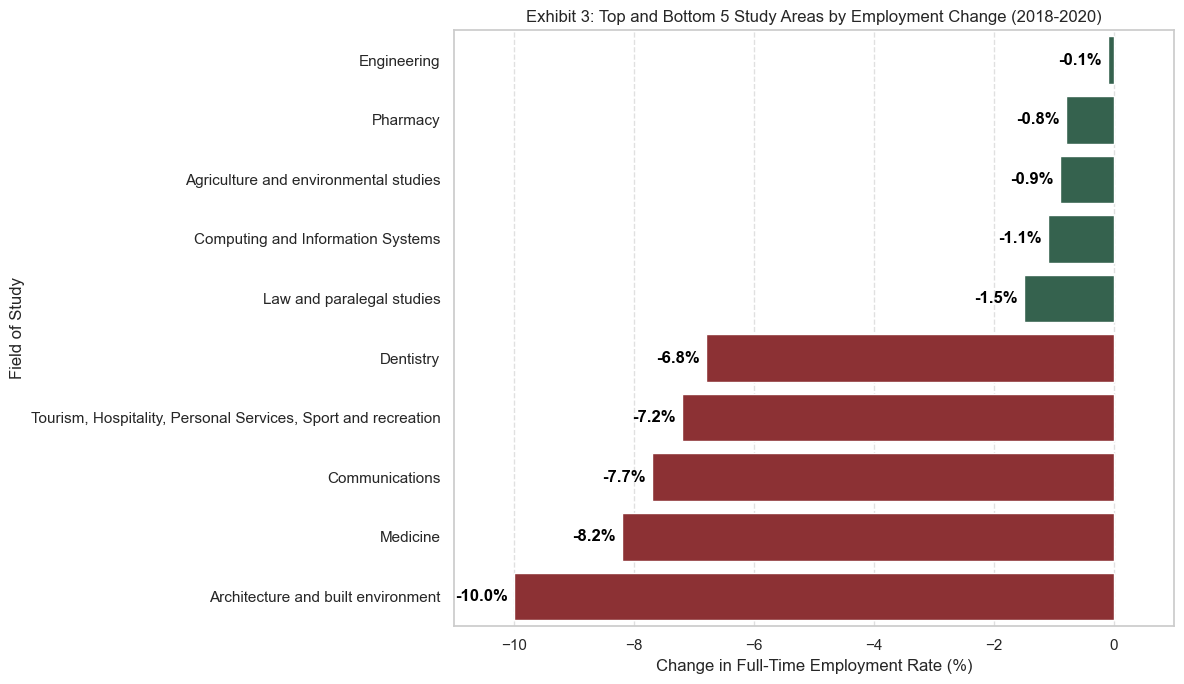

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Comparative Impact: Ranked Winners and Losers
# We will create a dual bar chart to show the top 5 winners and losers based on employment change

# Prepare the data by sorting by the change in Employment Rate
df_sorted = df_analysis.sort_values('FTE_Diff', ascending=False)

# Select Top 5 (highest resilience) and Bottom 5 (most affected)
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)
winners_losers = pd.concat([top_5, bottom_5])

plt.figure(figsize=(12, 7))

# Create a color palette: Green for the "Winners" (top), Red for "Losers" (bottom)
# Using specific hex codes for a professional look
# Updated to avoid the Future Warning: Added hue='Study_Area' and legend=False 
colors = ['#2d6a4f'] * 5 + ['#9b2226'] * 5
ax = sns.barplot(
    data=winners_losers, 
    x='FTE_Diff', 
    y='Study_Area', 
    palette=colors,
    hue='Study_Area',
    legend=False
) 

# Add data labels outside the bars for better readability
for i, v in enumerate(winners_losers['FTE_Diff']):
    # If value is negative, put text to the left; if positive, to the right
    ha_val = 'right' if v < 0 else 'left'
    offset = -0.1 if v < 0 else 0.1
    plt.text(v + offset, i, f"{v}%", color='black', fontweight='bold', va='center', ha=ha_val)

plt.title("Exhibit 3: Top and Bottom 5 Study Areas by Employment Change (2018-2020)")
plt.xlabel("Change in Full-Time Employment Rate (%)")
plt.ylabel("Field of Study")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlim(-11, 1) # Give a little extra room for the labels  
plt.tight_layout()
plt.show()

### Justification: Who was hit hardest by COVID-19? (Exhibit 3)
This chart shows which students had the easiest and hardest time finding jobs during the pandemic. It helps us answer our research question clearly: 
- **The Safe Group (Green):** **Engineering** and **Computing** students were very lucky. Their job rates barely changed (only about 1% drop). This is because even during lockdown, companies still needed computers, websites, and internet systems to work from home. 
- **The Hardest Hit Groups (Red):** **Architecture** and **Medicine** saw a huge drop in jobs (up to 10% drop). This happened because building sites were closed and many hospitals cancelled non-emergency surgeries during the pandemic. 
- **The Nursing vs. Medicine Difference:** Nursing is not in the "bottom 5" because nurses were needed everywhere to help with the virus, while some doctor jobs were put on hold. 

**Answer to the Research Question:**
The pandemic did not affect everyone the same way. It was like a "lottery." If you studied a "computer-based" subject, you were safe. But if you studied a subject that requires being there in person (i.e., Architecture), it was much harder to find a job in 2020. 


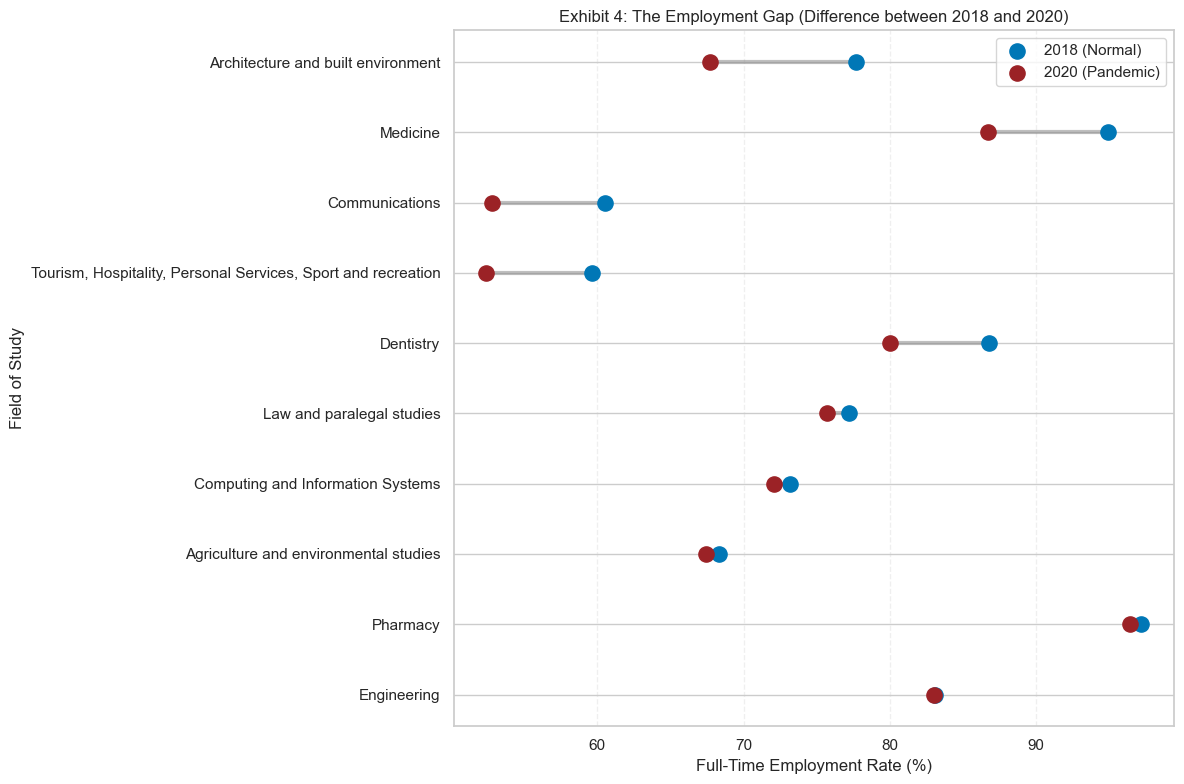

In [9]:
# 5. The "Distance Fallen": Before vs After Employment Rates
# This tells the story pf the actual gap created by the pandemic

# We use the same Top/Bottom 5 industries from the previous chart 
df_gap = winners_losers.copy()

plt.figure(figsize=(12, 8))

# Draw the lines (the "gap")
plt.hlines(y=df_gap['Study_Area'], xmin=df_gap['FTE_20'], xmax=df_gap['FTE_18'],
           color='grey', alpha=0.5, linewidth=3)

# Plot the 2018 points (The starting point)
plt.scatter(df_gap['FTE_18'], df_gap['Study_Area'], color='#0077b6', s=120, label='2018 (Normal)', zorder=3)

# Plot the 2020 points (The pandemic point) 
plt.scatter(df_gap['FTE_20'], df_gap['Study_Area'], color='#9b2226', s=120, label='2020 (Pandemic)', zorder=3)

plt.title("Exhibit 4: The Employment Gap (Difference between 2018 and 2020)")
plt.xlabel("Full-Time Employment Rate (%)")
plt.ylabel("Field of Study")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Justification: The Story of the Employment Gap (Exhibit 4)
This Dumbbell Plot visualizes the actual difference in employment rates by connecting the 2018 starting point (Blue) to the 2020 result (Red). The length of the grey line shows exactly how much each industry was affected by the downturn. 
- **Industries with High Stability (Short Lines):** In fields like **Engineering**, **Pharmacy**, and **Agriculture**, the Blue and Red dots are almost touching. The story here is relating to resilience, in which graduating during the pandemic had almost no impact on these students' ability to find full-time work. 
- **Industries with a Lost Opportunity (Long Lines):** In fields like **Architecture** and **Medicine**, there is a very long grey line. This represents a significant fall in job availability. Students in these areas faced a much harder job market in 2020 compared to those who graduated just two years earlier.
- **The Double Burden:** Areas like **Communications** and **Tourism** already had lower employment rates in 2018 and fell even further. This suggests that the downturn was particularly difficult for industries that were already in a weaker position. 

**Answer to the Research Question:**
The effect of graduating during the 2020 downturn was a **widening employment gap**. The story of the data is that the crisis was not felt equally. While some graduates were completely safe (short lines), others suffered a major loss in career opportunities (long lines), proving that the field of study was the most important factor in surviving the economic shock. 